<a href="https://colab.research.google.com/github/Sharris9/Test_1_IGP.pyclass/blob/main/notebooks2025/section04_DataQuality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Ken-Lau-Lab/single-cell-lectures/blob/main/notebooks2025/section04_DataQuality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# This notebook go through steps to generate ambient contamination metric plots to check the quality of a scRNA-seq dataset

## Preparation Steps
### 1. Install required packages

In [42]:
! pip install matplotlib==3.7.5
#==3.6.2

In [ ]:
! pip install scanpy==1.10.1
! pip install pandas==2.2.2
! pip install numpy==1.26.4

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 31.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 1.3.5
    Uninstalling pandas-1.3.5:
      Successfully uninstalled pandas-1.3.5
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 33.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.21.6
    Uninstalling numpy-1.21.6:
      Successfully uninstalled numpy-1.21.6


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 54.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 27.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 KB 12.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 KB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.0/300.0 KB 22.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 965.4/965.4 KB 52.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 64.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 KB 7.7 MB/s eta 0:00:00
  Created wheel for umap-learn: filename=umap_learn-0.5.3-py3-none-any.whl size=82829 sha256=20118a7afe4ea2595a5790c7eed02f1c7d1f2601d6ccc

In [43]:
!pip install setuptools==65.5.0 wheel==0.38.4

In [44]:
!pip install dropkick==1.2.8

In [45]:
!pip install POT

clone the github that has codes for ambient contamination analysis

In [46]:
! git clone https://github.com/Ken-Lau-Lab/AmbiQuant.git

fatal: destination path 'AmbiQuant' already exists and is not an empty directory.


### 2. Import packages

In [47]:
import scanpy as sc

In [48]:
import sys
import numpy as np
import pandas as pd

In [49]:
from matplotlib import pyplot as plt

In [50]:
import dropkick as dk

At this point, if dropkick cannot be imported, uncomment the next cell and run it. Then, <font color='red'>restart runtime</font> after installing. Run all the <font color='#b225f6'>import</font> cells after restart the runtime

In [ ]:
#! pip install matplotlib

Found existing installation: matplotlib 3.6.2
Uninstalling matplotlib-3.6.2:
  Would remove:
    /usr/local/lib/python3.8/dist-packages/matplotlib-3.6.2-py3.8-nspkg.pth
    /usr/local/lib/python3.8/dist-packages/matplotlib-3.6.2.dist-info/*
    /usr/local/lib/python3.8/dist-packages/matplotlib/*
    /usr/local/lib/python3.8/dist-packages/mpl_toolkits/axes_grid1/*
    /usr/local/lib/python3.8/dist-packages/mpl_toolkits/axisartist/*
    /usr/local/lib/python3.8/dist-packages/mpl_toolkits/mplot3d/*
    /usr/local/lib/python3.8/dist-packages/mpl_toolkits/tests/*
    /usr/local/lib/python3.8/dist-packages/pylab.py
Proceed (Y/n)? Y
  Successfully uninstalled matplotlib-3.6.2


In [51]:
sys.path.append("./content/QuantBio_HW4")
sys.path.append("./content/QuantBio_HW4")
#add the path of the contamination python files to the notebook's search path so that they can be imported

In [15]:
import quality_control_function as qc_functions
import plot_quality_score as qc_plts
import QCPipe

### 3. Download data files

In [18]:
! mkdir QB_HW4
# this line created a folder '7017_YX_1' in the current working directory

In [19]:
! curl -O -J -L https://www.dropbox.com/scl/fo/mbxe9nfe0kmd432b65p2n/AGr8xth-08yYwzcdEnX_Dcs?rlkey=03r5iwlxlgpv1waxkwso9hxkc&st=0cemb5n8&dl=0
! curl -O -J -L https://www.dropbox.com/scl/fo/fy052zrkfescrv0py15s2/AMUCWx973SvHDgmQauHmhtA?rlkey=4lzdk56xt72p3tx5xd8shqco7&st=wl0zxmlg&dl=0
! curl -O -J -L https://www.dropbox.com/scl/fo/4piv8a1f8nefi4v3ldlui/ABCFkwMpJn7ZNzxUOiKBH2s?rlkey=fhg3c8bdiziib7lqdks33mjuk&st=4uer8221&dl=0
# download data from the url

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    17  100    17    0     0     19      0 --:--:-- --:--:-- --:--:--    19
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
curl: (23) Failed writing header
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    17  100    17    0     0     14      0  0:00:01  0:00:01 --:--:--    14
100 96.2M  100 96.2M    0     0  31.7M      0  0:00:03  0:00:03 --:--:-- 51.5M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    17  100    17    0     0     17      0  0:00:01 --:--:--  0:00:01    17
100  192M  100  192M    0     0  37.0M      0  0:00:05  0:00:05 --:--:-- 47.1M


In [20]:
! unzip cmraw_sparse.zip -d dataset_A.zip
! unzip cmraw_sparse.zip -d dataset_B.zip
! unzip cmraw_sparse.zip -d dataset_C.zip
#unzipping the folder to get separated files

unzip:  cannot find or open cmraw_sparse.zip, cmraw_sparse.zip.zip or cmraw_sparse.zip.ZIP.
unzip:  cannot find or open cmraw_sparse.zip, cmraw_sparse.zip.zip or cmraw_sparse.zip.ZIP.
unzip:  cannot find or open cmraw_sparse.zip, cmraw_sparse.zip.zip or cmraw_sparse.zip.ZIP.


note the 3 enssential files for RNA-seq data: the count matrix, a list of barcodes and a list of gene names (feature)

## Generating metric plots
### 1. Read data into an anndata object and cut to 10,000 barcodes

Calculating QC Metrics


/content/./AmbiQuant/QCPipe_dir/qc_utils.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  secant_coef=data_cumsum[adata_in.obs.shape[0]-1]/adata_in.obs.shape[0]
/content/./AmbiQuant/QCPipe_dir/qc_utils.py:46: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  inflection_percentiles_inds = np.percentile(x_vals[x_vals>inflection_points[0]],inflection_percentiles).astype(int)


Inflection point at [3401 5772 8143] for [0, 15, 30] percentiles of greatest secant distances
the original dataset has 19210 cells. Cut to 10000 cells


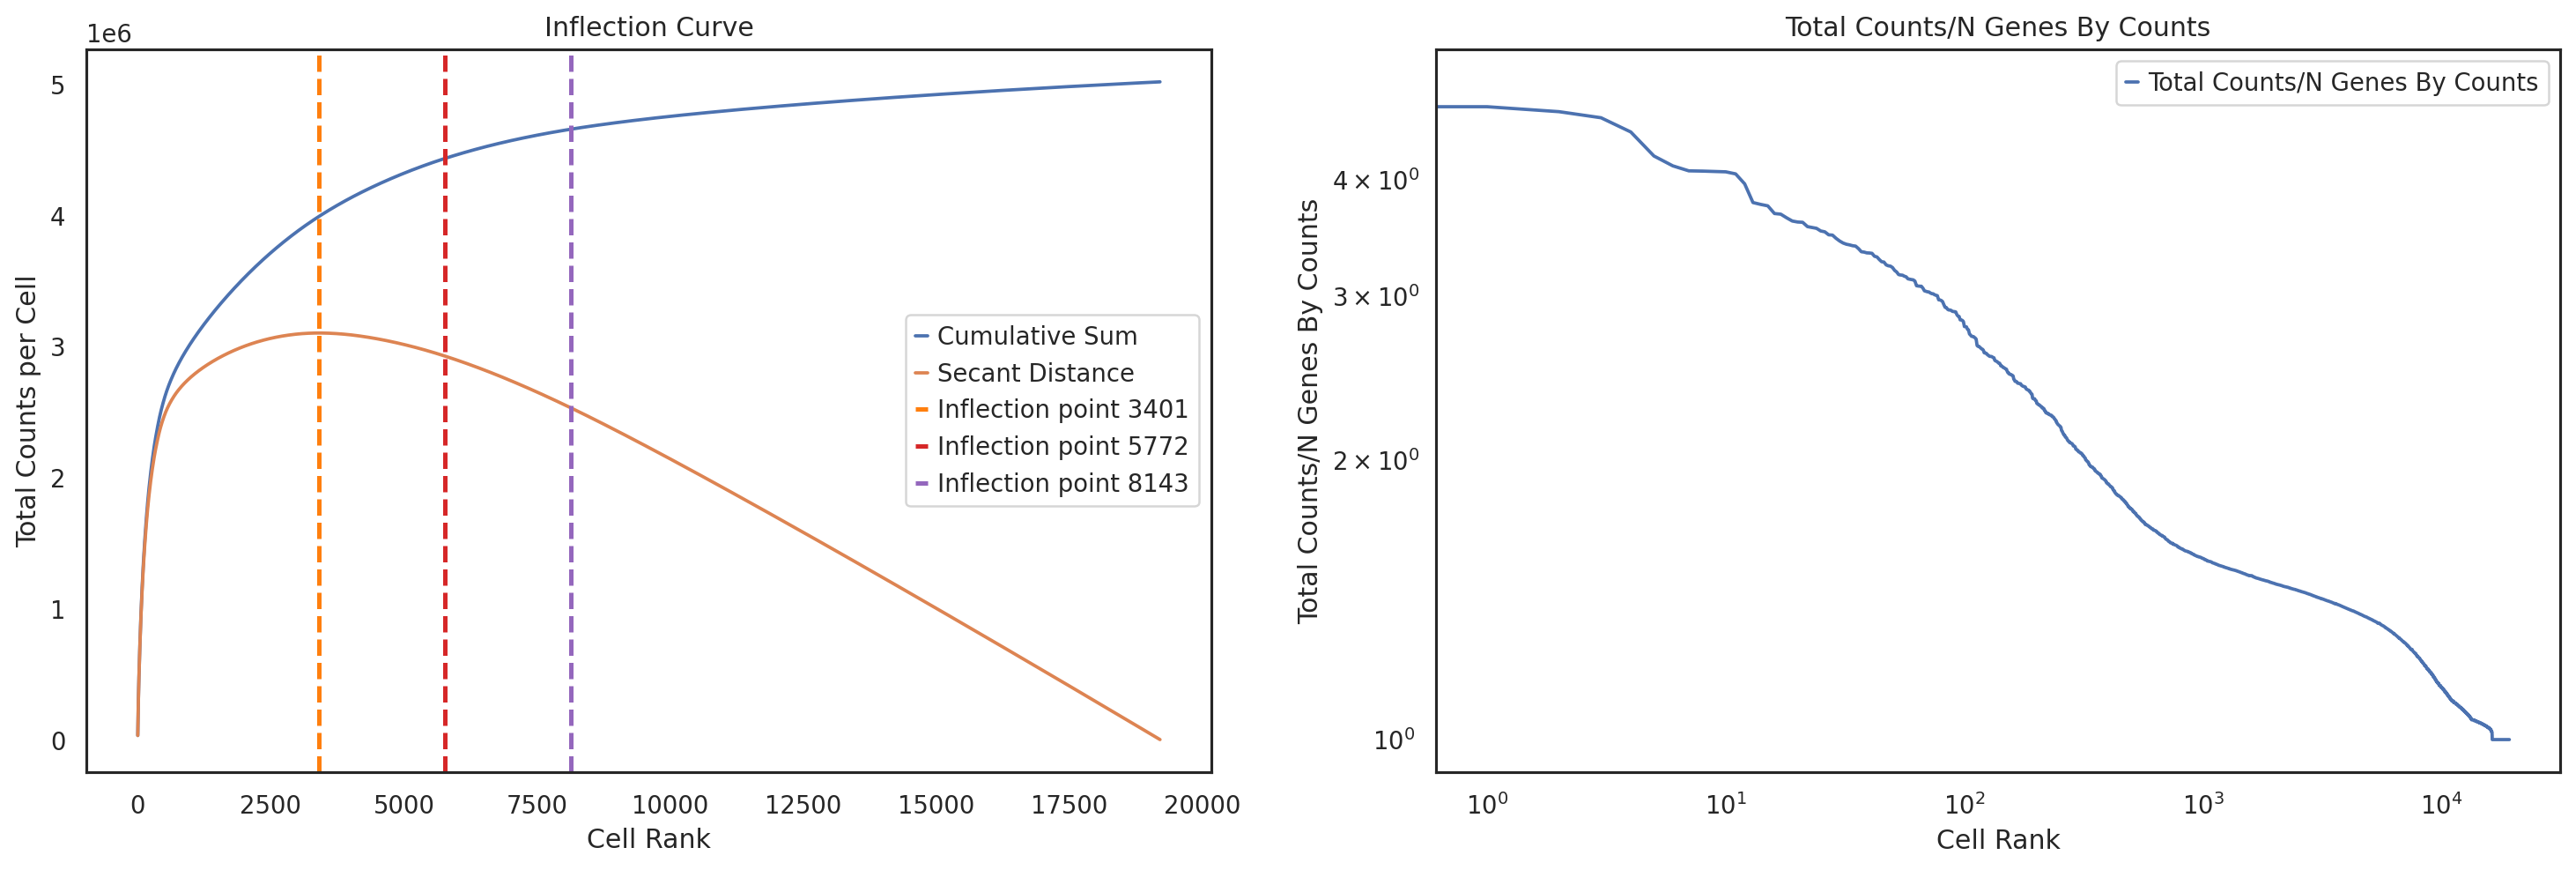

In [21]:
dat_A = qc_functions.cut_off_from_dropset( "/content/QB_HW4/A", gene_file_delim="\t", barcode_file_delim="\t", mito_tag="mt-"  )
# the first parameter is the path name where the data files are stored
# the second and third param are specifiying delimiter used in the files (csv needs to use ',', tsv needs to use '\t' ... )
# more parameter specification can be found in the documentation


Calculating QC Metrics


/content/./AmbiQuant/QCPipe_dir/qc_utils.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  secant_coef=data_cumsum[adata_in.obs.shape[0]-1]/adata_in.obs.shape[0]
/content/./AmbiQuant/QCPipe_dir/qc_utils.py:46: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  inflection_percentiles_inds = np.percentile(x_vals[x_vals>inflection_points[0]],inflection_percentiles).astype(int)


Inflection point at [ 7197 11558 15920] for [0, 15, 30] percentiles of greatest secant distances
the original dataset has 36277 cells. Cut to 10000 cells


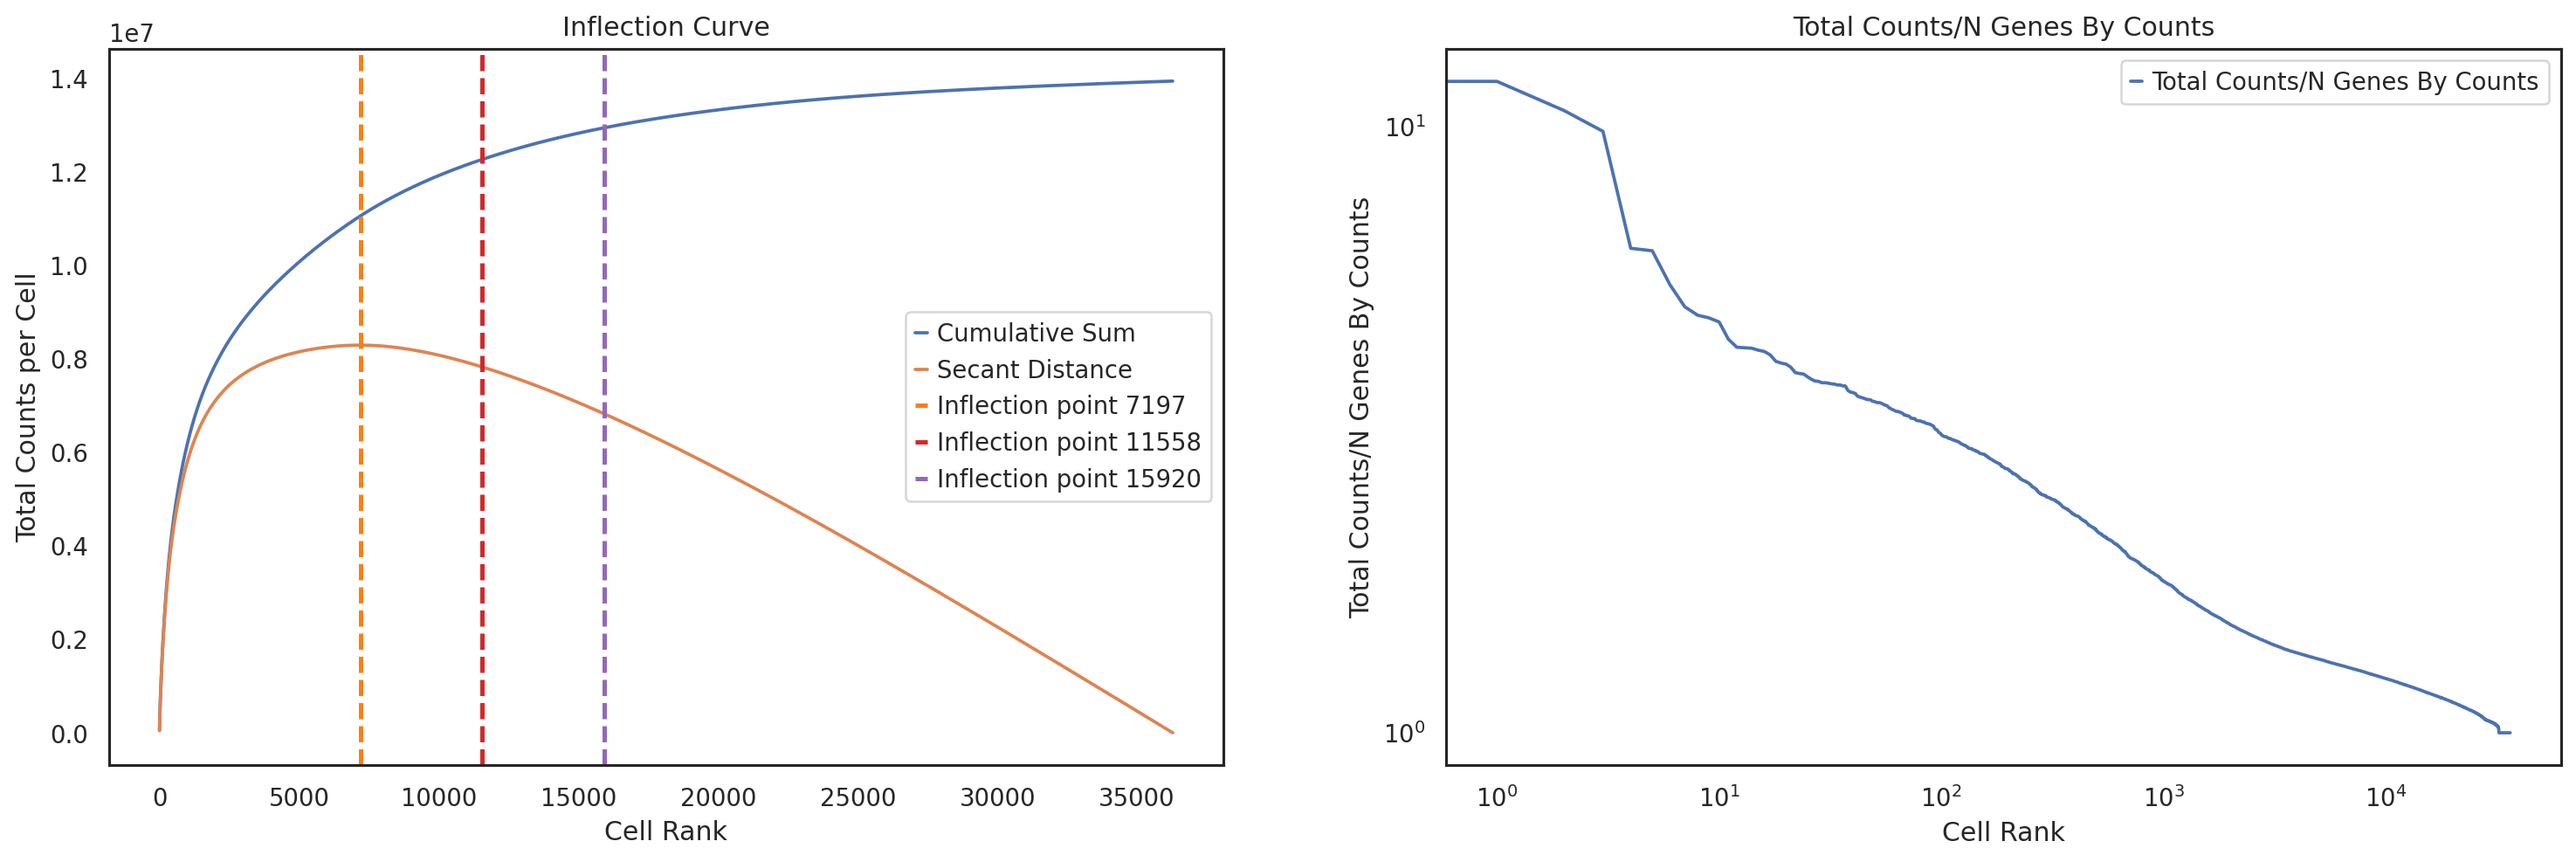

In [22]:
dat_B = qc_functions.cut_off_from_dropset( "/content/QB_HW4/B", gene_file_delim="\t", barcode_file_delim="\t", mito_tag="mt-"  )

Calculating QC Metrics


/content/./AmbiQuant/QCPipe_dir/qc_utils.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  secant_coef=data_cumsum[adata_in.obs.shape[0]-1]/adata_in.obs.shape[0]
/content/./AmbiQuant/QCPipe_dir/qc_utils.py:46: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  inflection_percentiles_inds = np.percentile(x_vals[x_vals>inflection_points[0]],inflection_percentiles).astype(int)


Inflection point at [14919 29571 44224] for [0, 15, 30] percentiles of greatest secant distances
the original dataset has 112606 cells. Cut to 10000 cells


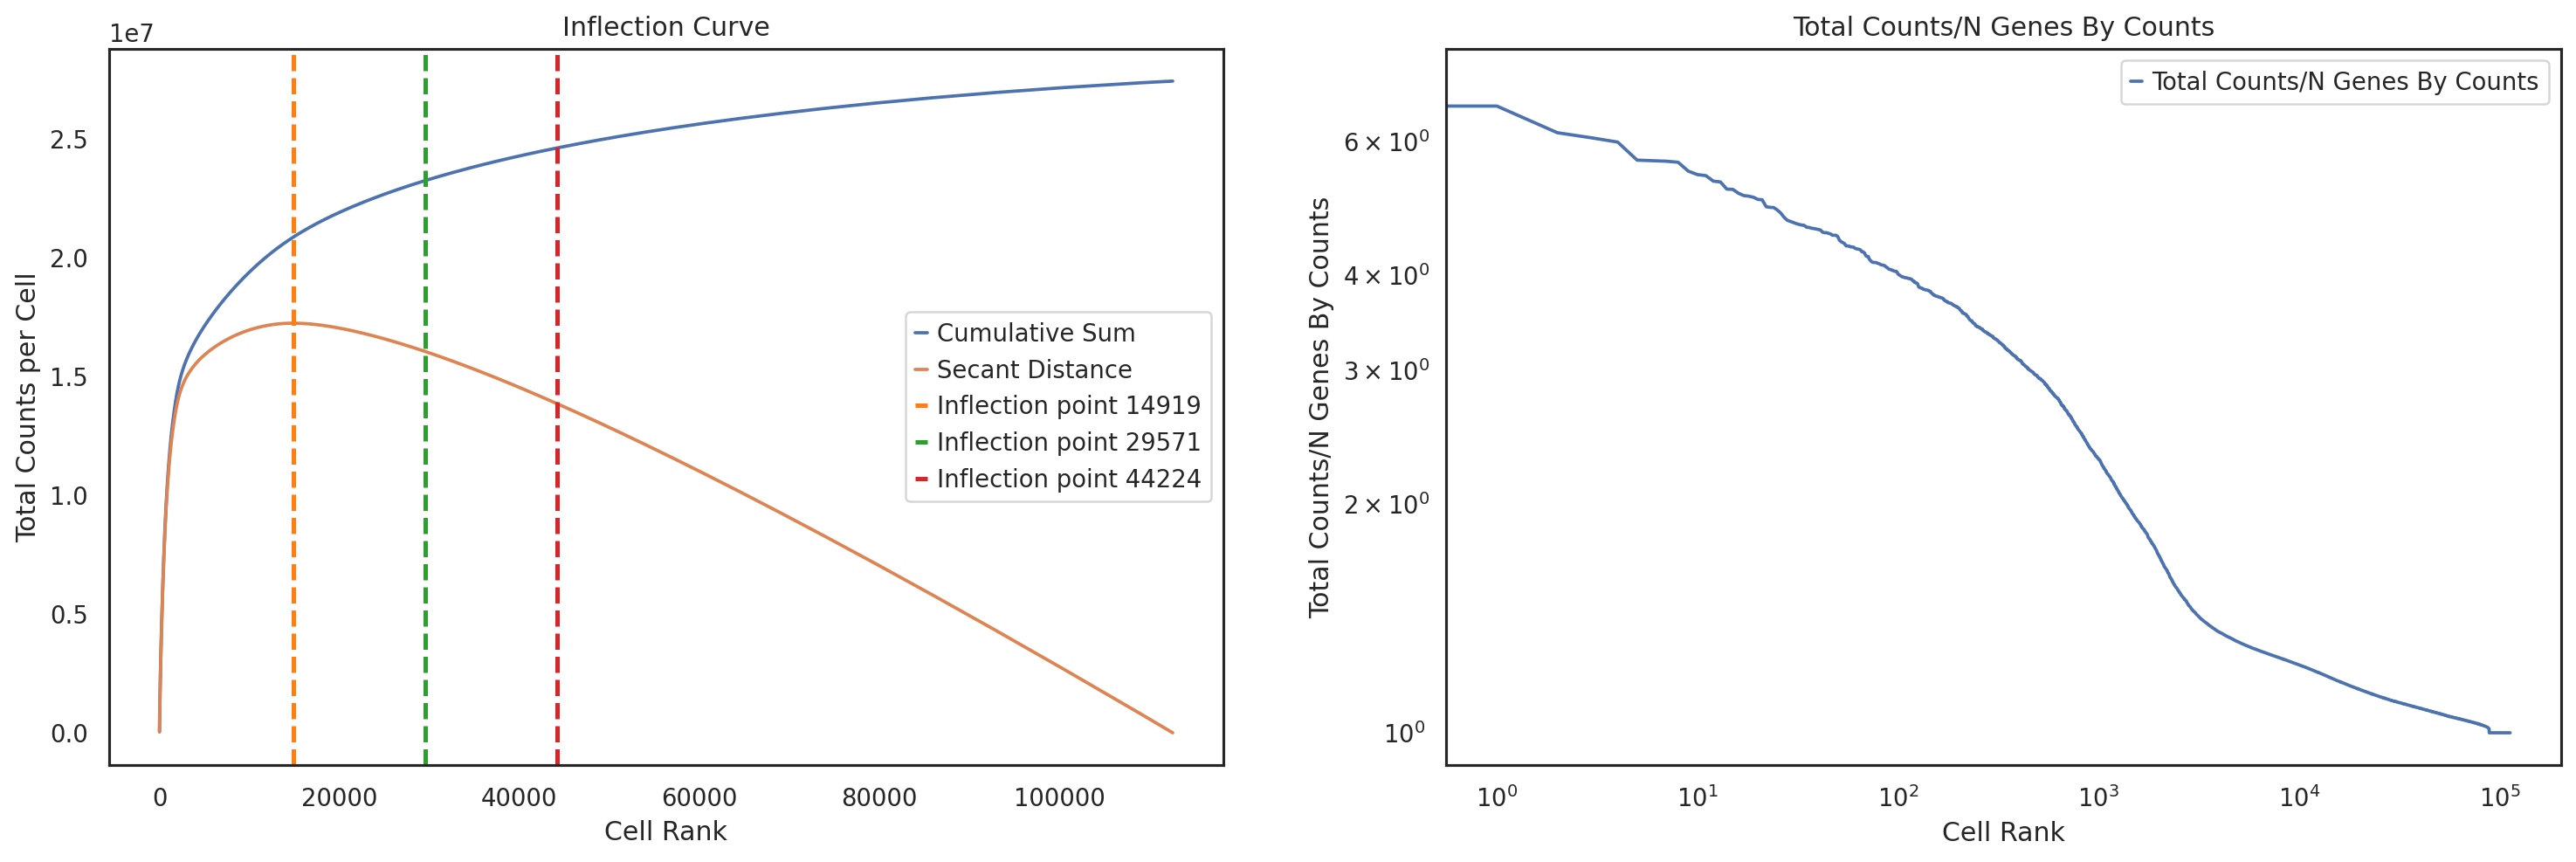

In [23]:
dat_C = qc_functions.cut_off_from_dropset( "/content/QB_HW4/C", gene_file_delim="\t", barcode_file_delim="\t", mito_tag="mt-"  )

In [24]:
data_combined = sc.concat([dat_A, dat_C], join = 'inner')

/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [25]:
data_combined.obs.shape

(20000, 11)

In [28]:
dat_B.obs[['total_counts','n_genes_by_counts','pct_counts_mitocondria' ]].describe()

KeyError: "['pct_counts_mitocondria'] not in index"

As I mentioned earlier, note there were 50,000 cells in the raw file initially, but most of them are empty droplets as you can see the plateau. Conventionally we keep 10,000 cells to proceed.

### 2. Generate the metric plots

Top 1 ambient genes have dropout rates between 1.93 and 1.93 percent:
	['Reg3b']


/content/./AmbiQuant/quality_control_function.py:460: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adata.var.pct_dropout_by_counts[


Overall score: 0.3749826389344744


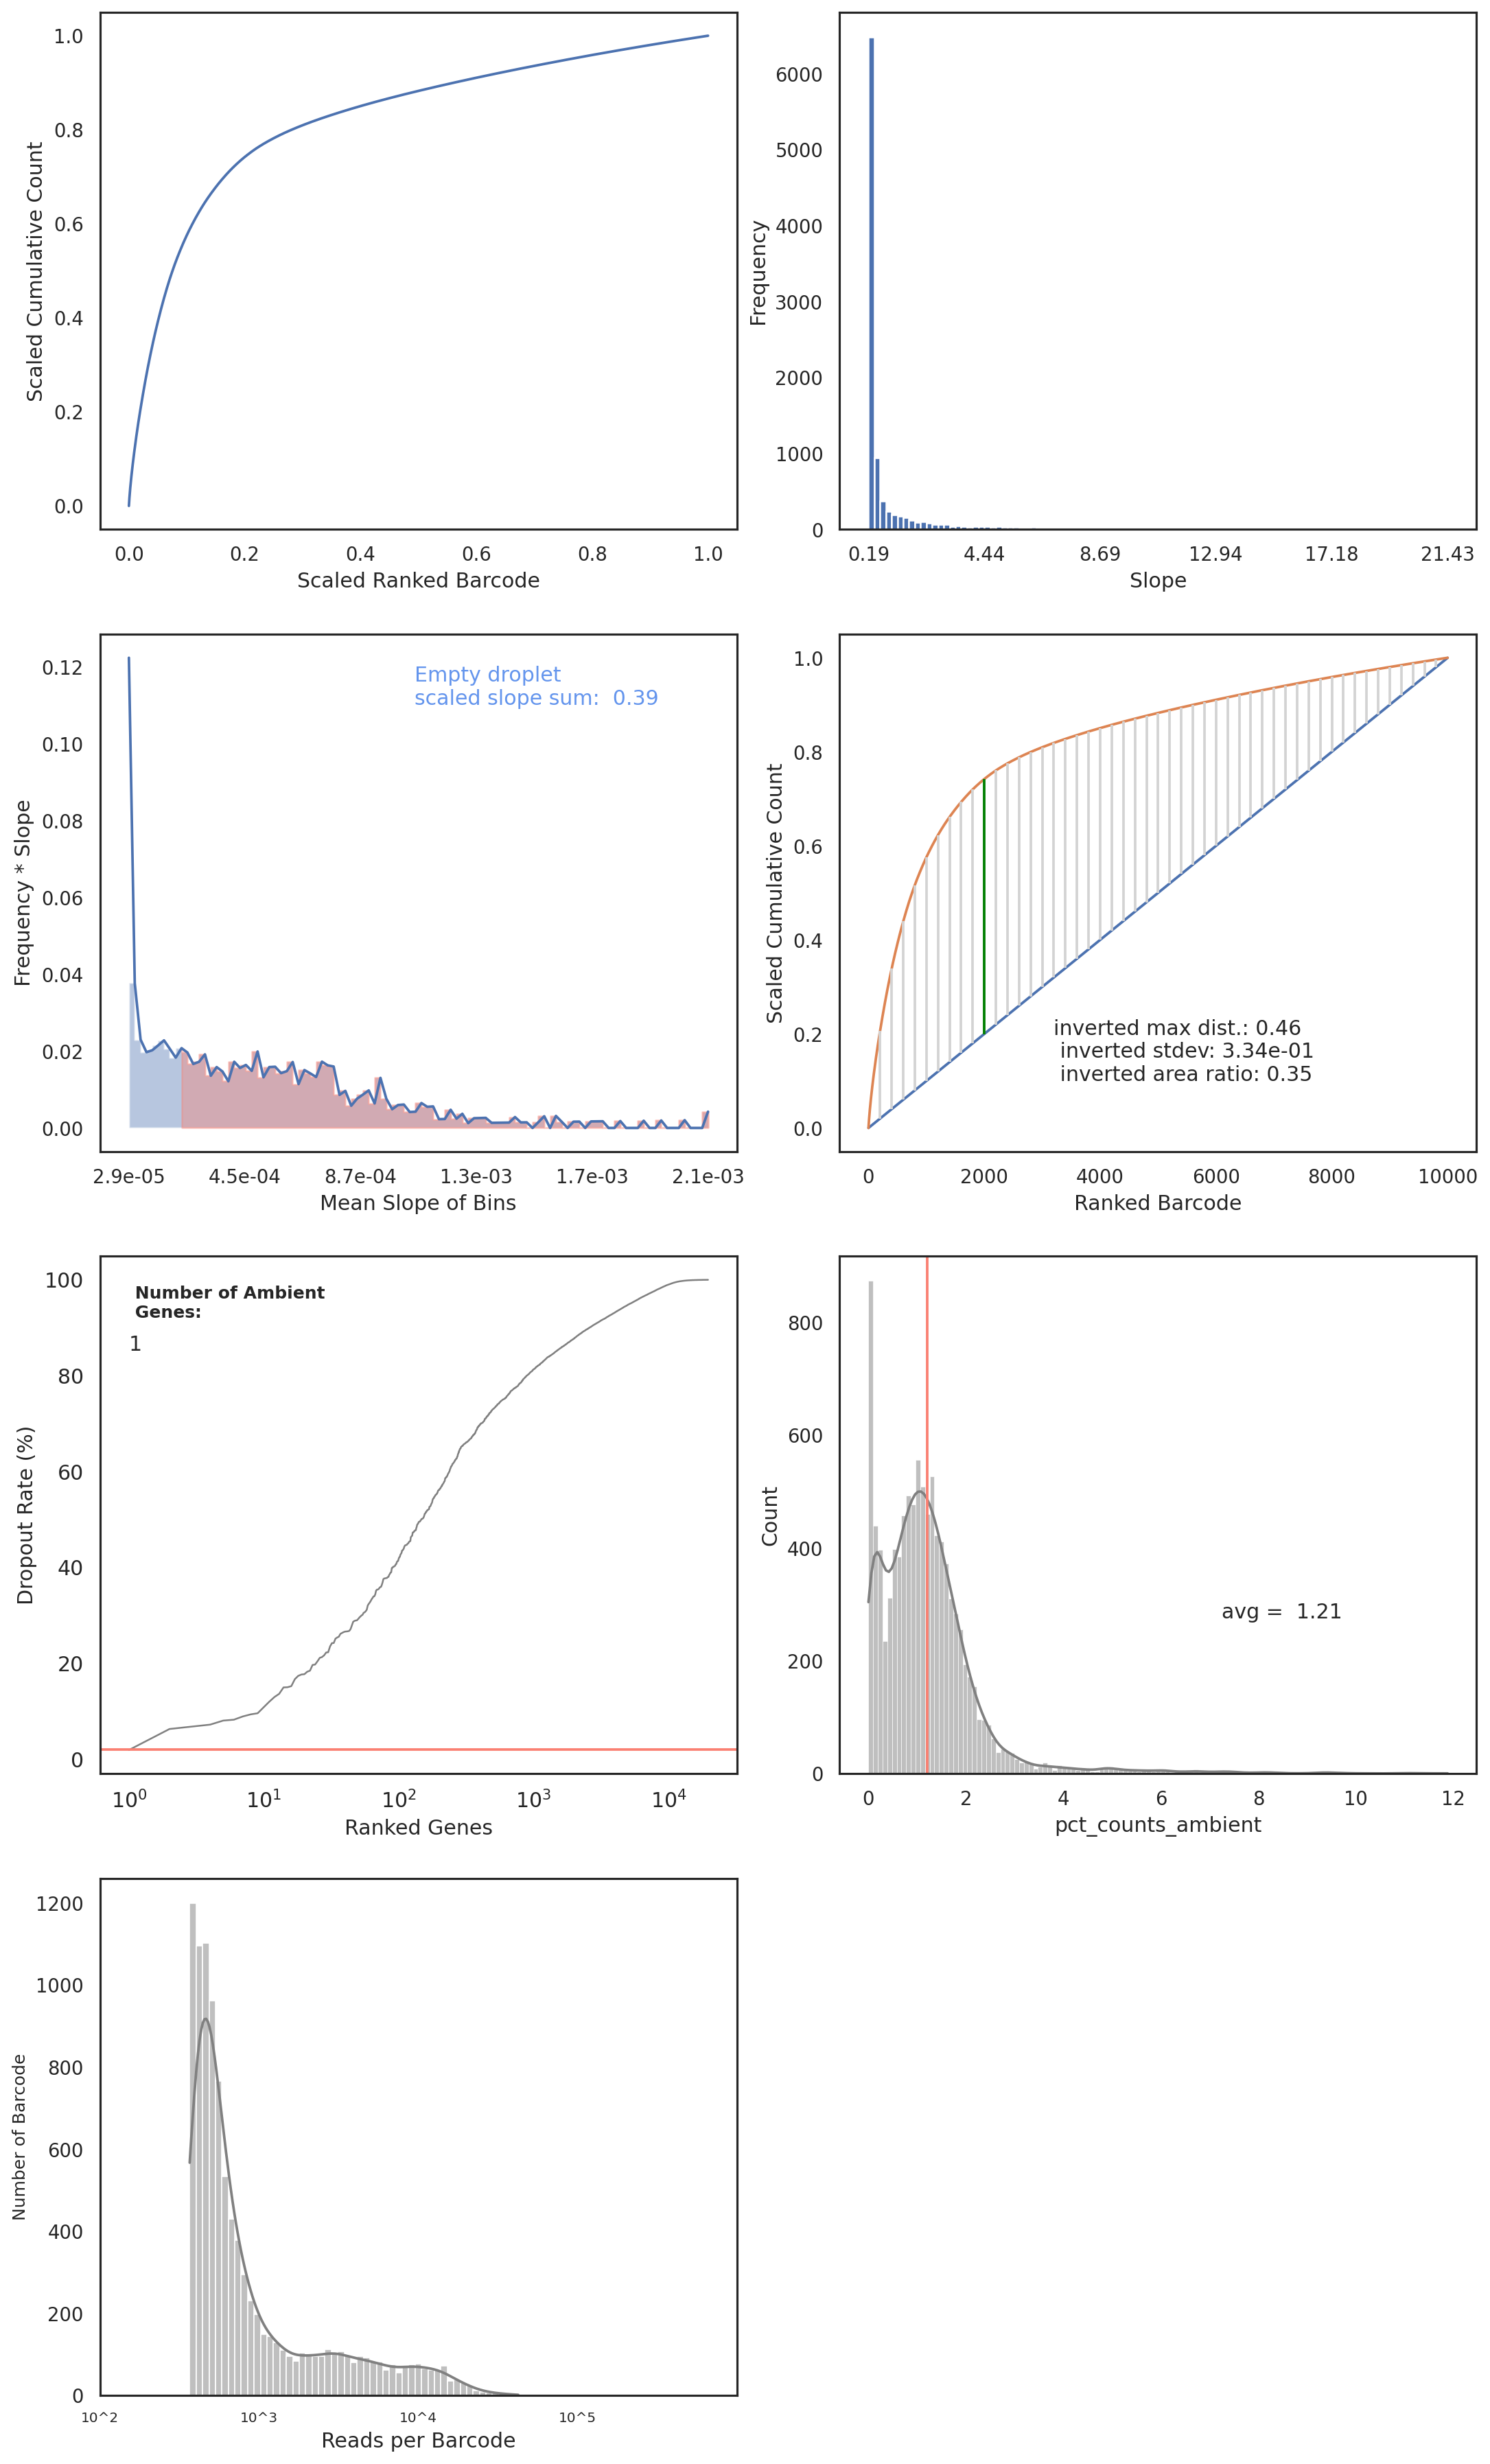

In [88]:
ret = qc_plts.formatted_figures_inverted(dat, ncols = 2, )

In [154]:
dat
#check information in this anndata object

AnnData object with n_obs × n_vars = 10000 × 19659
    obs: 'total_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_Mitochondrial', 'log1p_total_counts_Mitochondrial', 'pct_counts_Mitochondrial'
    var: 'Mitochondrial', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mito', 'ambient'
    uns: 'Order', 'inflection1', 'inflection_fold'
    layers: 'raw_counts'

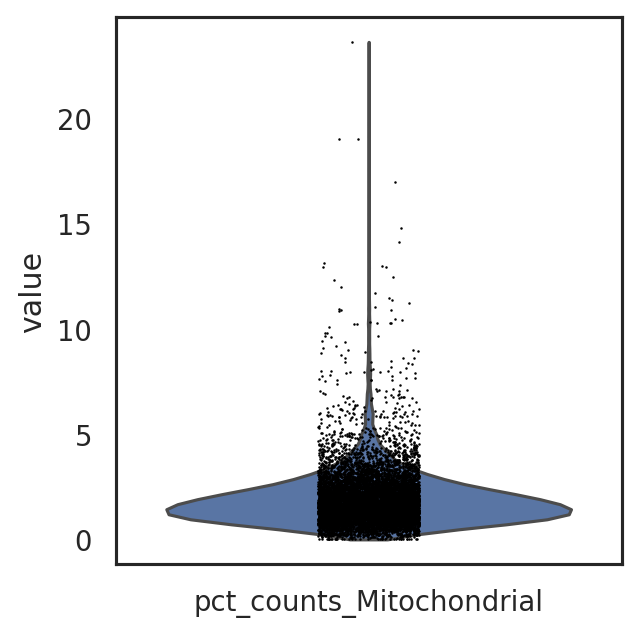

In [155]:
 sc.pl.violin(dat, "pct_counts_Mitochondrial")
 # Visualize one of the standard qc metrics with scanpy pl module functions

<Axes: >

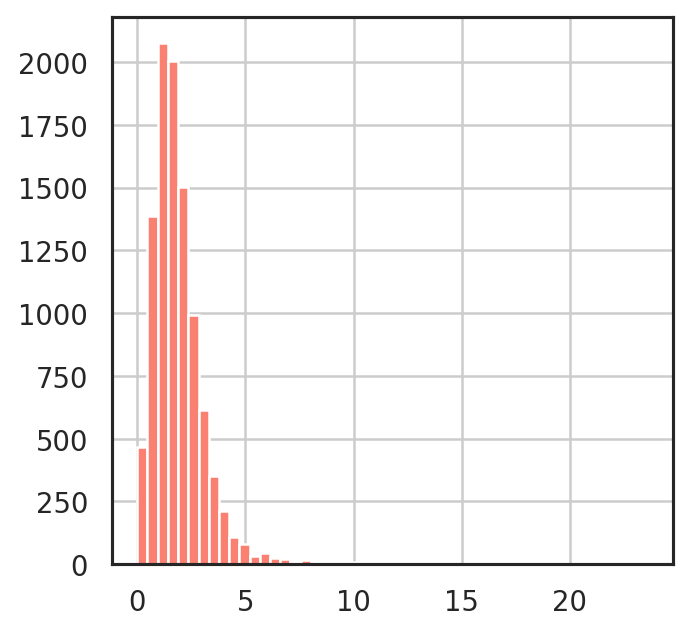

In [156]:
dat.obs["pct_counts_Mitochondrial"].hist(bins = 50, color ='salmon')
# can also use matplotlib
# this hist() is a method called on the dataframe 'dat.obs["pct_counts_Mitochondrial"]', which is a subset of dat.obs dataframe

<Axes: >

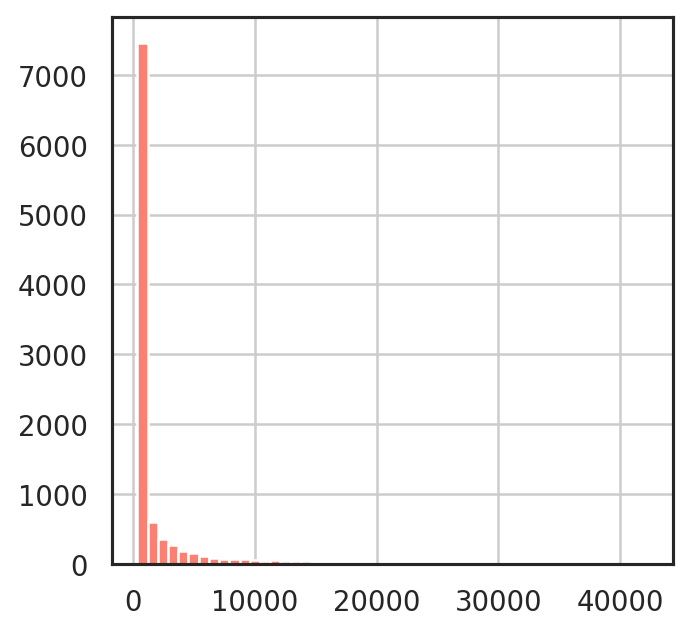

In [157]:
dat.obs["total_counts"].hist(bins = 50, color ='salmon')

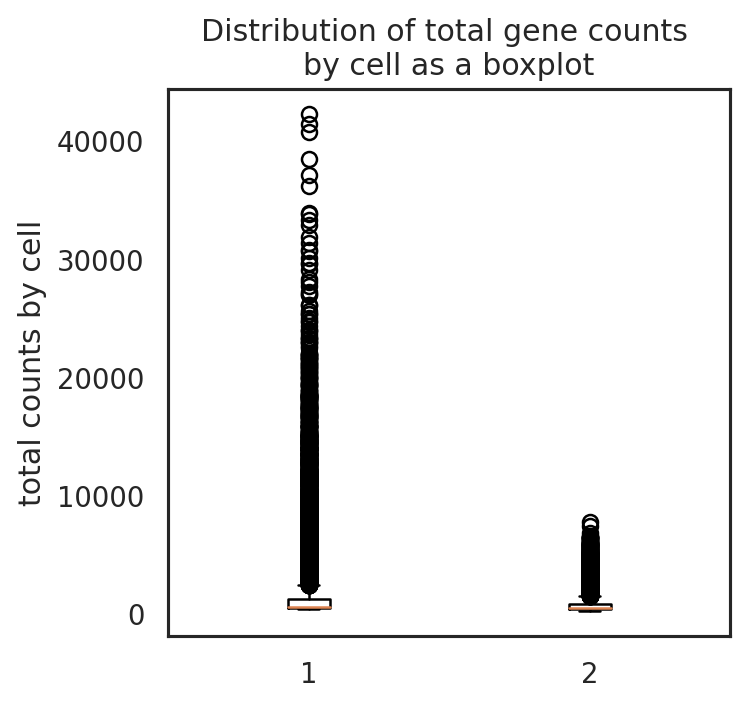

In [158]:
p = plt.boxplot( dat.obs[ ['total_counts', 'n_genes_by_counts']]  )
plt.ylabel( "total counts by cell")
plt.title( "Distribution of total gene counts \nby cell as a boxplot")
plt.show()

In [159]:
dat.obs[['total_counts', 'n_genes_by_counts' ]].describe()

,total_counts,n_genes_by_counts
count,10000.000000,10000.000000
mean,1937.904785,882.510000
std,3664.437012,1003.733036
min,366.000000,194.000000
25%,447.000000,356.000000
50%,573.000000,443.000000
75%,1240.000000,825.250000
max,42280.000000,7795.000000


## Basic QC steps from scanpy and show the stat summary

In [160]:
dat2 = dat.copy()

In [161]:
sc.pp.filter_cells(dat2, min_genes=200)
sc.pp.filter_genes(dat2, min_cells=3)

In [162]:
dat2 = dat2[dat2.obs.n_genes_by_counts < 2500, :] # remove potential doublets ( droplets that captures 2 (>1) cells)
dat2 = dat2[dat2.obs.pct_counts_Mitochondrial < 5, :] #remove cells with high mitochondrial percentage

In [163]:
dat2.n_obs # check how many cells left

8901

In [164]:
dat2.obs[['total_counts', 'n_genes_by_counts' ]].describe()

,total_counts,n_genes_by_counts
count,8901.000000,8901.000000
mean,990.928772,619.019211
std,1105.572876,466.497778
min,366.000000,232.000000
25%,441.000000,352.000000
50%,546.000000,423.000000
75%,876.000000,625.000000
max,9161.000000,2499.000000


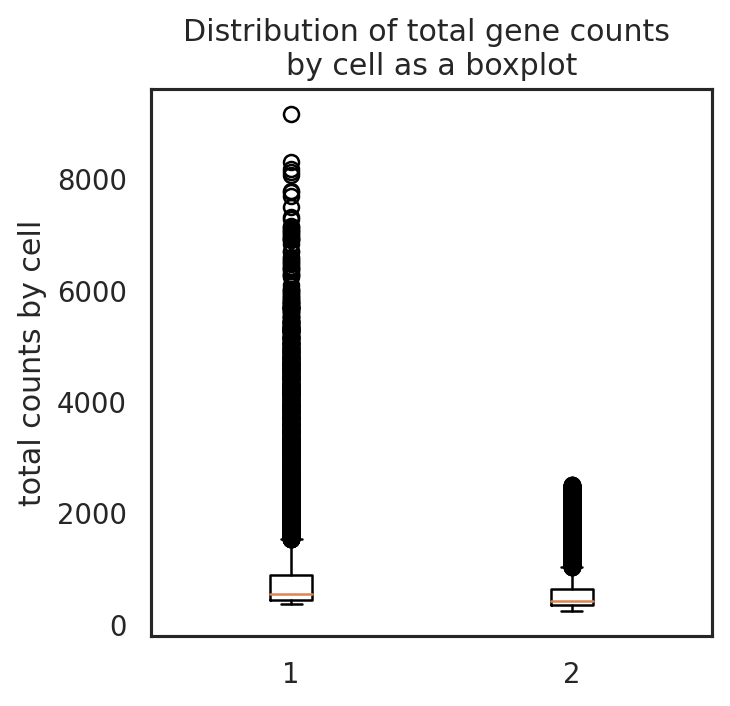

In [165]:
p = plt.boxplot( dat2.obs[ ['total_counts', 'n_genes_by_counts']]  )
plt.ylabel( "total counts by cell")
plt.title( "Distribution of total gene counts \nby cell as a boxplot")
plt.show()

## try initial filter with dropkick and show the stat summary

Ignoring 297 genes with zero total counts
Top 10 ambient genes have dropout rates between 1.93 and 10.86 percent:
	['Reg3b', 'mt-Nd1', 'Sprr2a2', 'Car1', 'Lypd8', 'Eef1a1', 'Krt8', 'Actb', 'Sprr2a1', 'Muc2']
Determining 2000 highly variable genes
Setting arcsinh_norm layer to .X
Thresholding on heuristics for training labels:
	['arcsinh_n_genes_by_counts']
Ignoring 6690 barcodes below first threshold on arcsinh_n_genes_by_counts
Training dropkick with alphas:
	[0.1]


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   5 out of   5 | elapsed:  1.1min finished
/usr/local/lib/python3.11/dist-packages/dropkick/api.py:623: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adata.obs.dropkick_score.fillna(0, inplace=True)  # fill ignored cells with zeros
/usr/local/lib/python3.11/dist-packages/dropkick/api.py:630: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Th

Chosen lambda value:
	[0.07027185]
Assigning scores and labels
Done!

Calculating QC Metrics


/content/./AmbiQuant/QCPipe_dir/qc_utils.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  secant_coef=data_cumsum[adata_in.obs.shape[0]-1]/adata_in.obs.shape[0]
/content/./AmbiQuant/QCPipe_dir/qc_utils.py:46: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  inflection_percentiles_inds = np.percentile(x_vals[x_vals>inflection_points[0]],inflection_percentiles).astype(int)
<ipython-input-166-f1c30b250632>:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, u

Inflection point at [1997 3197 4397] for [0, 15, 30] percentiles of greatest secant distances


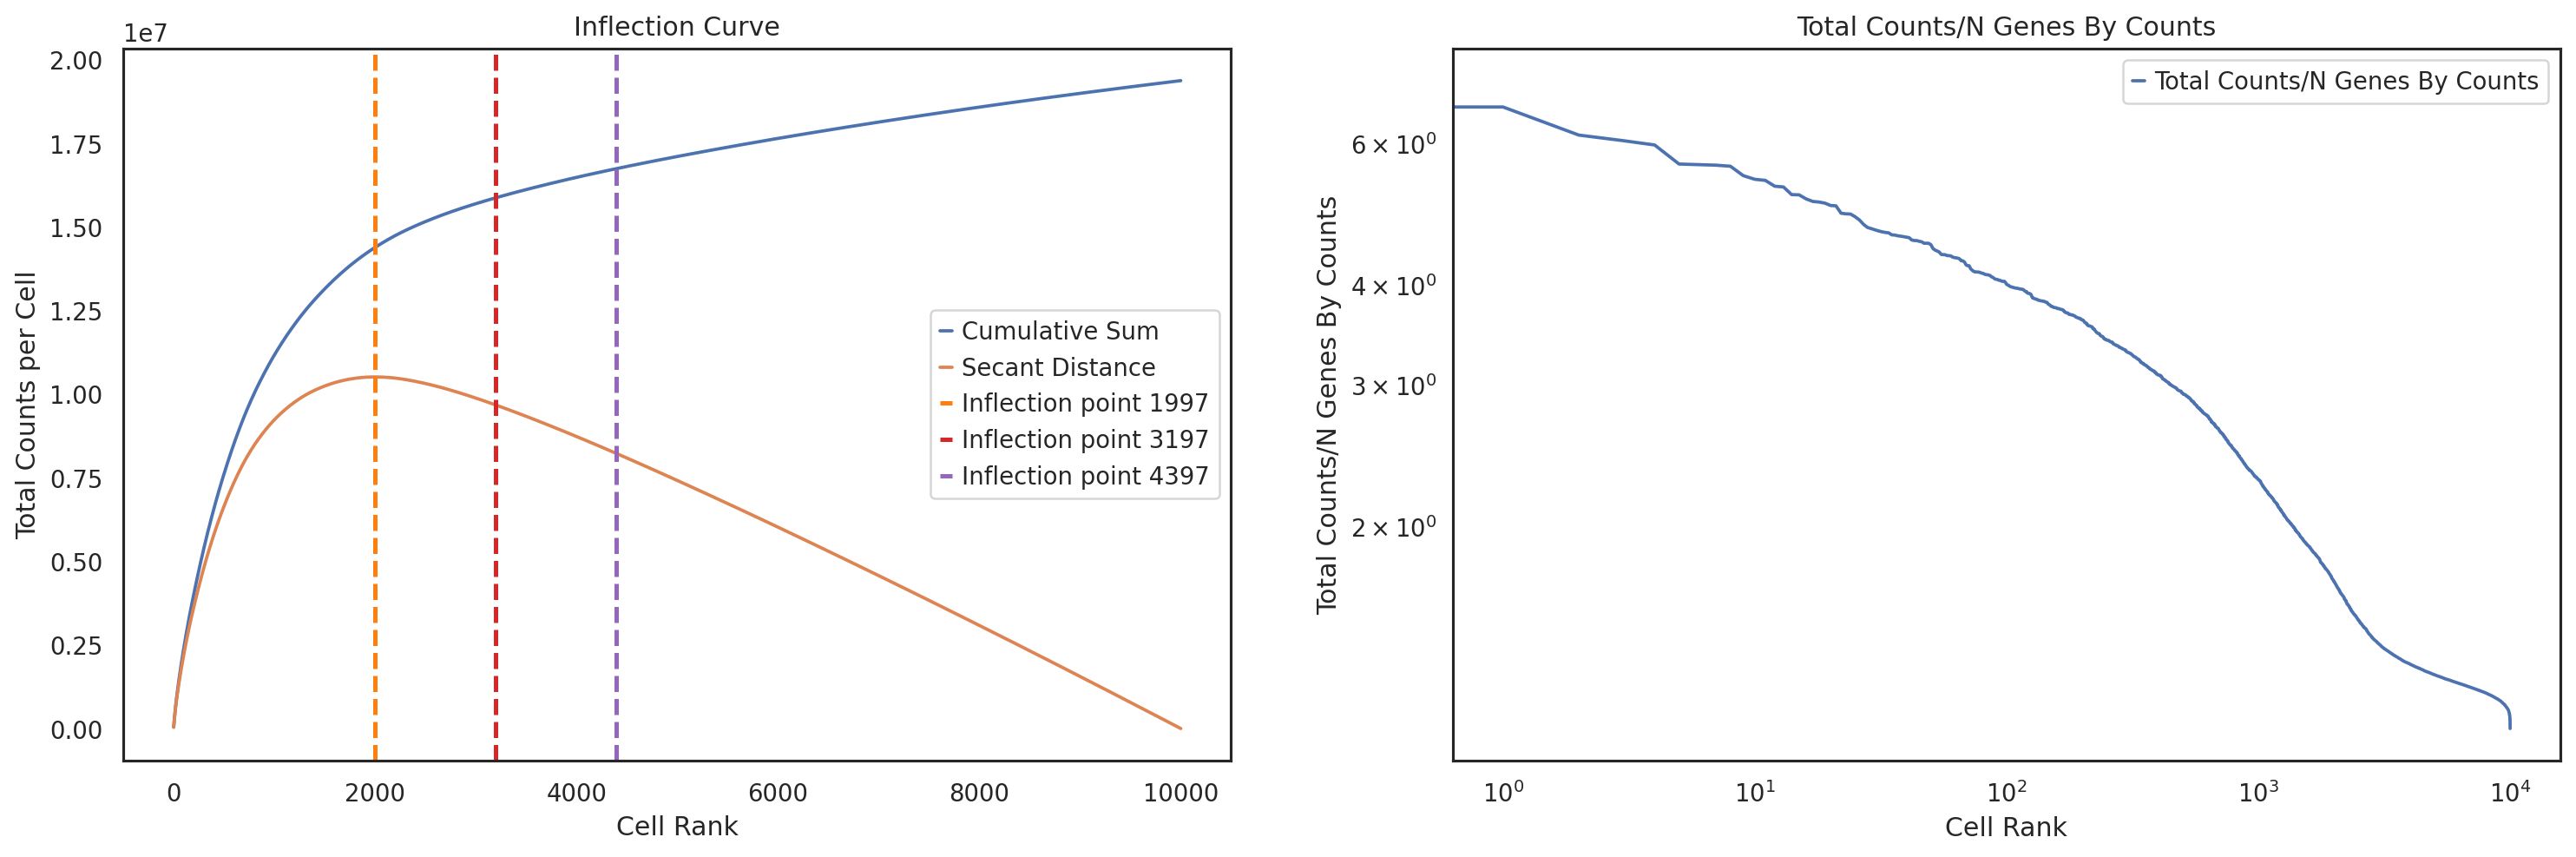

In [166]:
dk.dropkick(dat)
dat.obs['dropkick_label']= dat.obs['dropkick_label'].astype(str)
inf = QCPipe.qc.find_inflection(dat)
sc.pp.filter_cells(dat,min_counts=dat[inf[0]].obs.total_counts[0])
dat.raw = dat.copy()

In [167]:
dat = dat[dat.obs['dropkick_label'] == 'True'] # keep the cells with True dropkick label

In [168]:
dat.n_obs # check how many cells left

1535

In [169]:
dat.obs[['total_counts', 'n_genes_by_counts' ]].describe()

,total_counts,n_genes_by_counts
count,1535.000000,1535.000000
mean,7742.443848,2728.141368
std,5814.579102,1194.381107
min,1937.000000,807.000000
25%,3381.000000,1736.000000
50%,5750.000000,2478.000000
75%,10450.500000,3525.000000
max,41448.000000,7795.000000


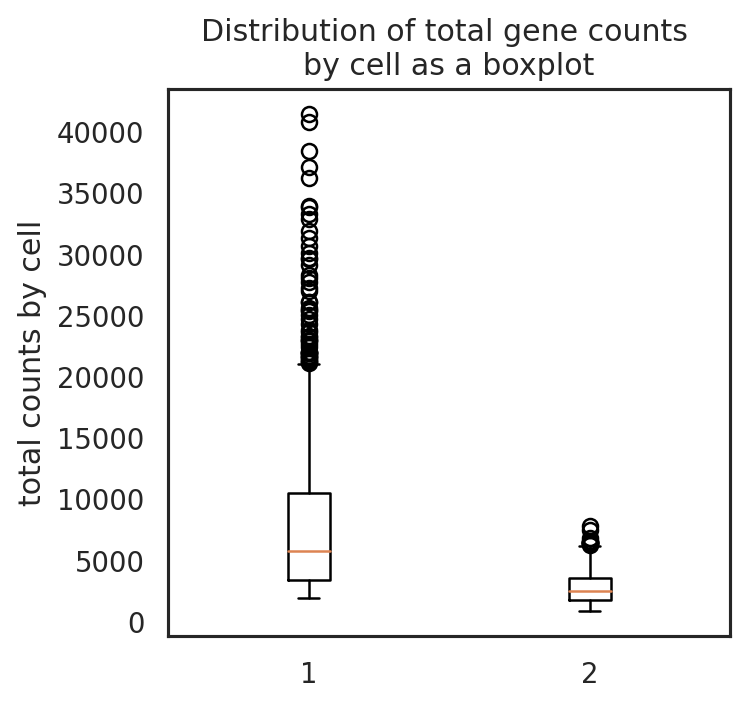

In [170]:
p = plt.boxplot( dat.obs[ ['total_counts', 'n_genes_by_counts']]  )
plt.ylabel( "total counts by cell")
plt.title( "Distribution of total gene counts \nby cell as a boxplot")
plt.show()

## Working with Filtered Data

In [177]:
#%cd /content/ #change back to the home directory

! curl -O -J -L https://www.dropbox.com/s/tvn3s1413julpjs/YX1_7017_cells.h5ad?dl=0
#download the filtered dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   136  100   136    0     0    820      0 --:--:-- --:--:-- --:--:--   819
100    17  100    17    0     0     22      0 --:--:-- --:--:-- --:--:--    22
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0^C


In [178]:
filtered_dat = sc.read("./YX1_7017_cells.h5ad")

In [179]:
filtered_dat

AnnData object with n_obs × n_vars = 783 × 18894
    obs: 'total_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_Mitochondrial', 'log1p_total_counts_Mitochondrial', 'pct_counts_Mitochondrial', 'n_genes_by_counts_zscore', 'relative_transcript_diversity_threshold', 'dropkick_score', 'dropkick_label', 'arcsinh_n_genes_by_counts', 'n_counts', 'leiden', 'Cell_Selection'
    var: 'Mitochondrial', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'dropkick_coef', 'mean', 'std'
    uns: 'Order', 'dropkick_args', 'dropkick_label_colors', 'dropkick_thresholds', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [180]:
standard_qc_metrics =  ['total_counts', 'n_genes_by_counts',"pct_counts_in_top_200_genes", 'pct_counts_Mitochondrial', "dropkick_score" , 'leiden']

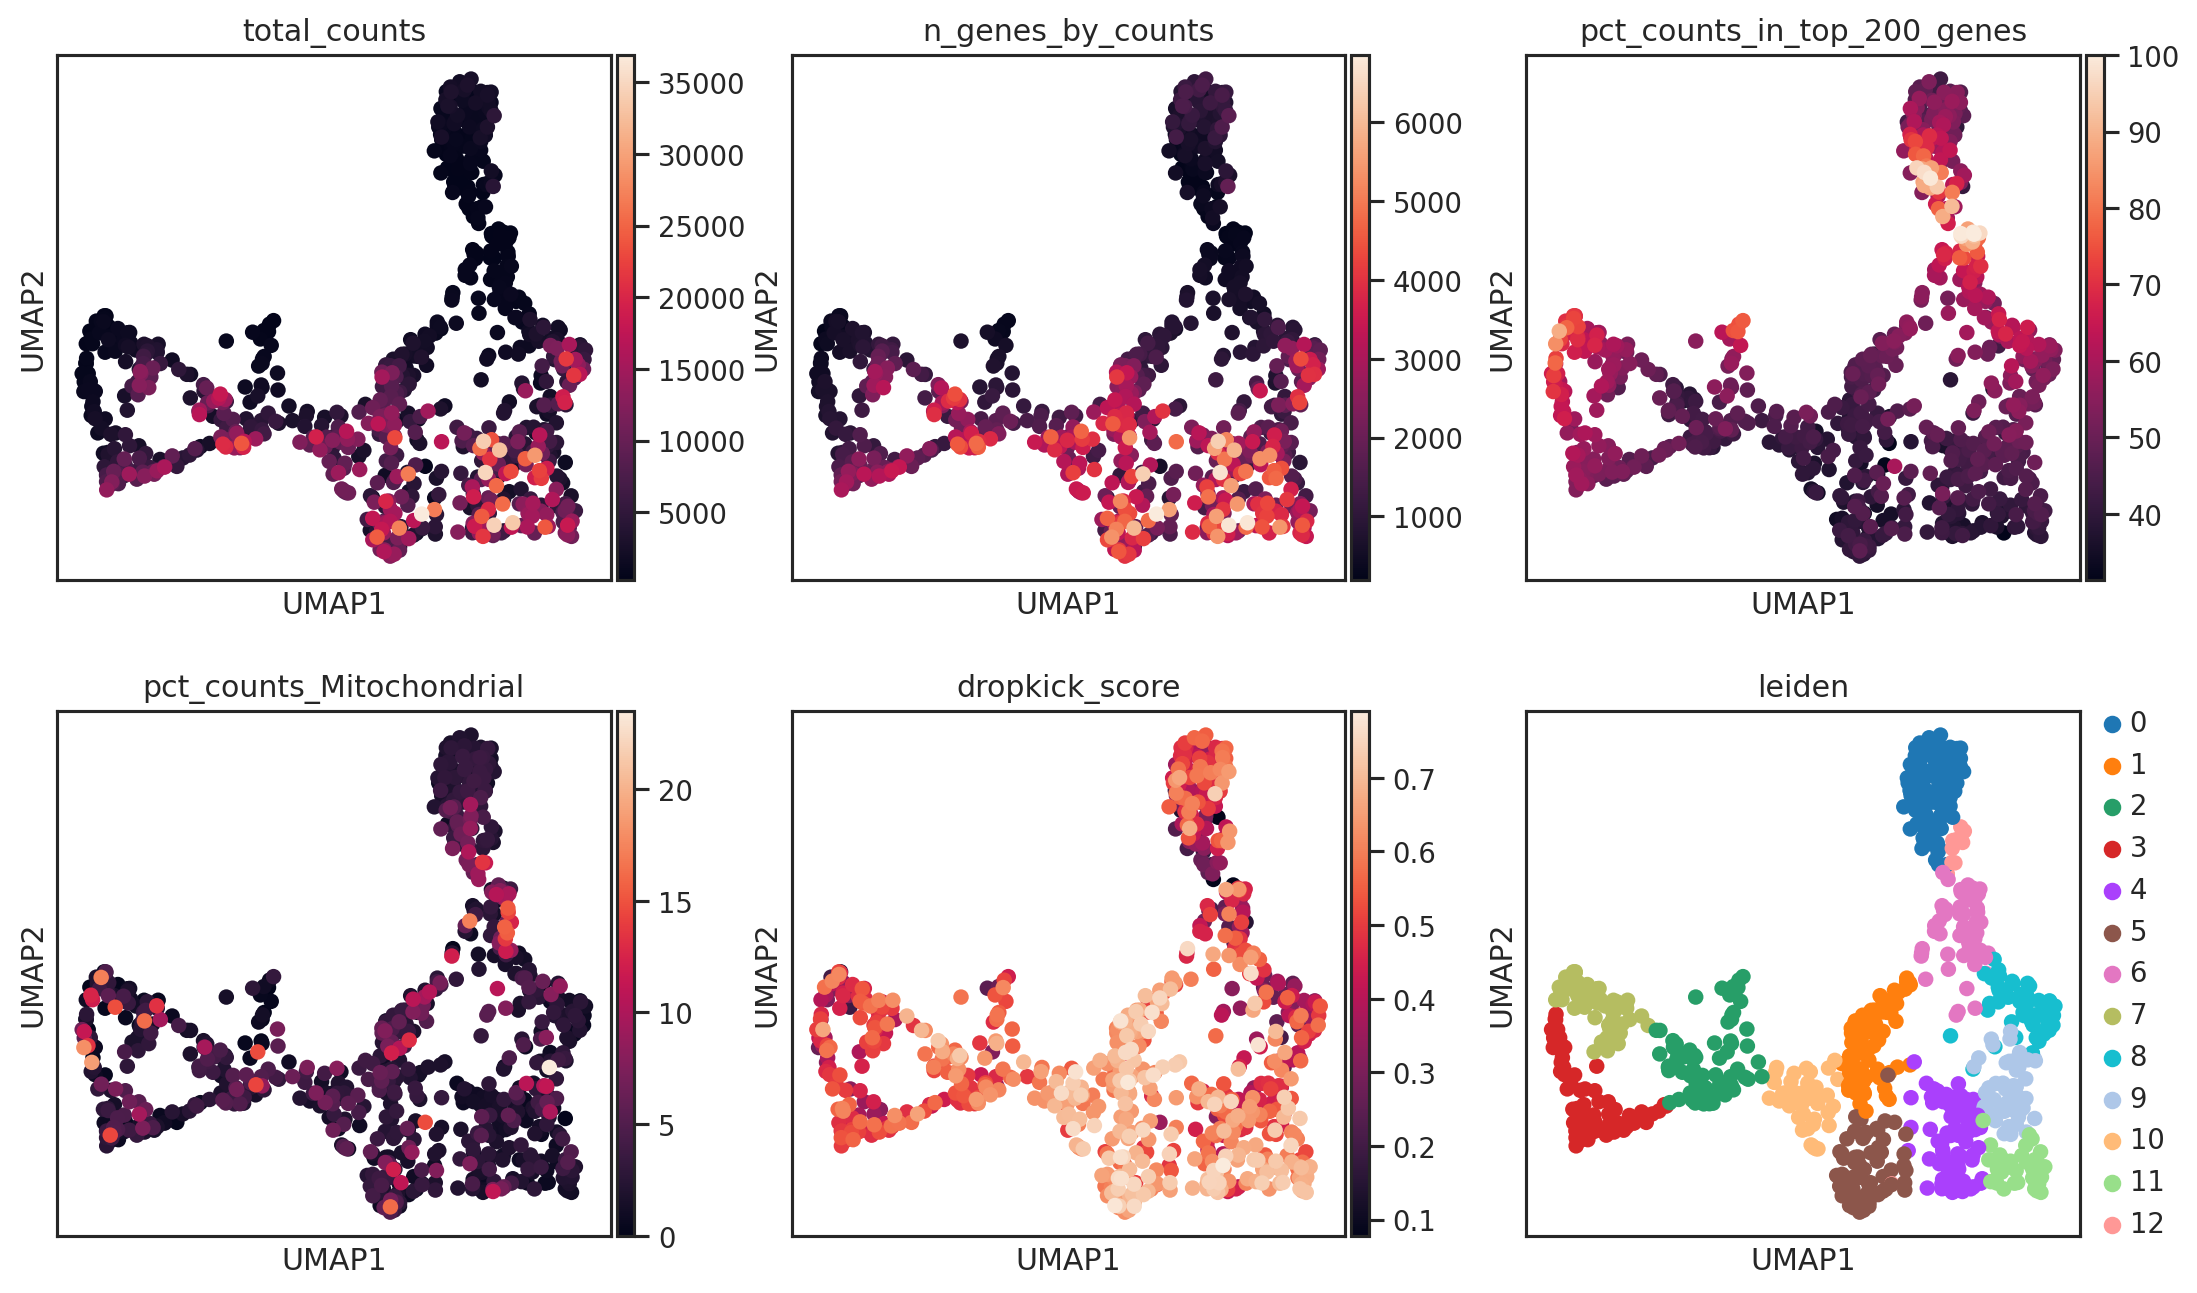

In [181]:
sc.pl.umap(filtered_dat, color = standard_qc_metrics, ncols=3)

In [182]:
ne_markers = ['Cd8a',  'Cd4', 'Jchain', 'Col1a1'] # Non-epithelial cell markers

In [183]:
markers = ['Guca2a',  'Lgr5', 'Mki67',  'Muc2', 'Chga', 'Dclk1'] # epithelial cell type markers

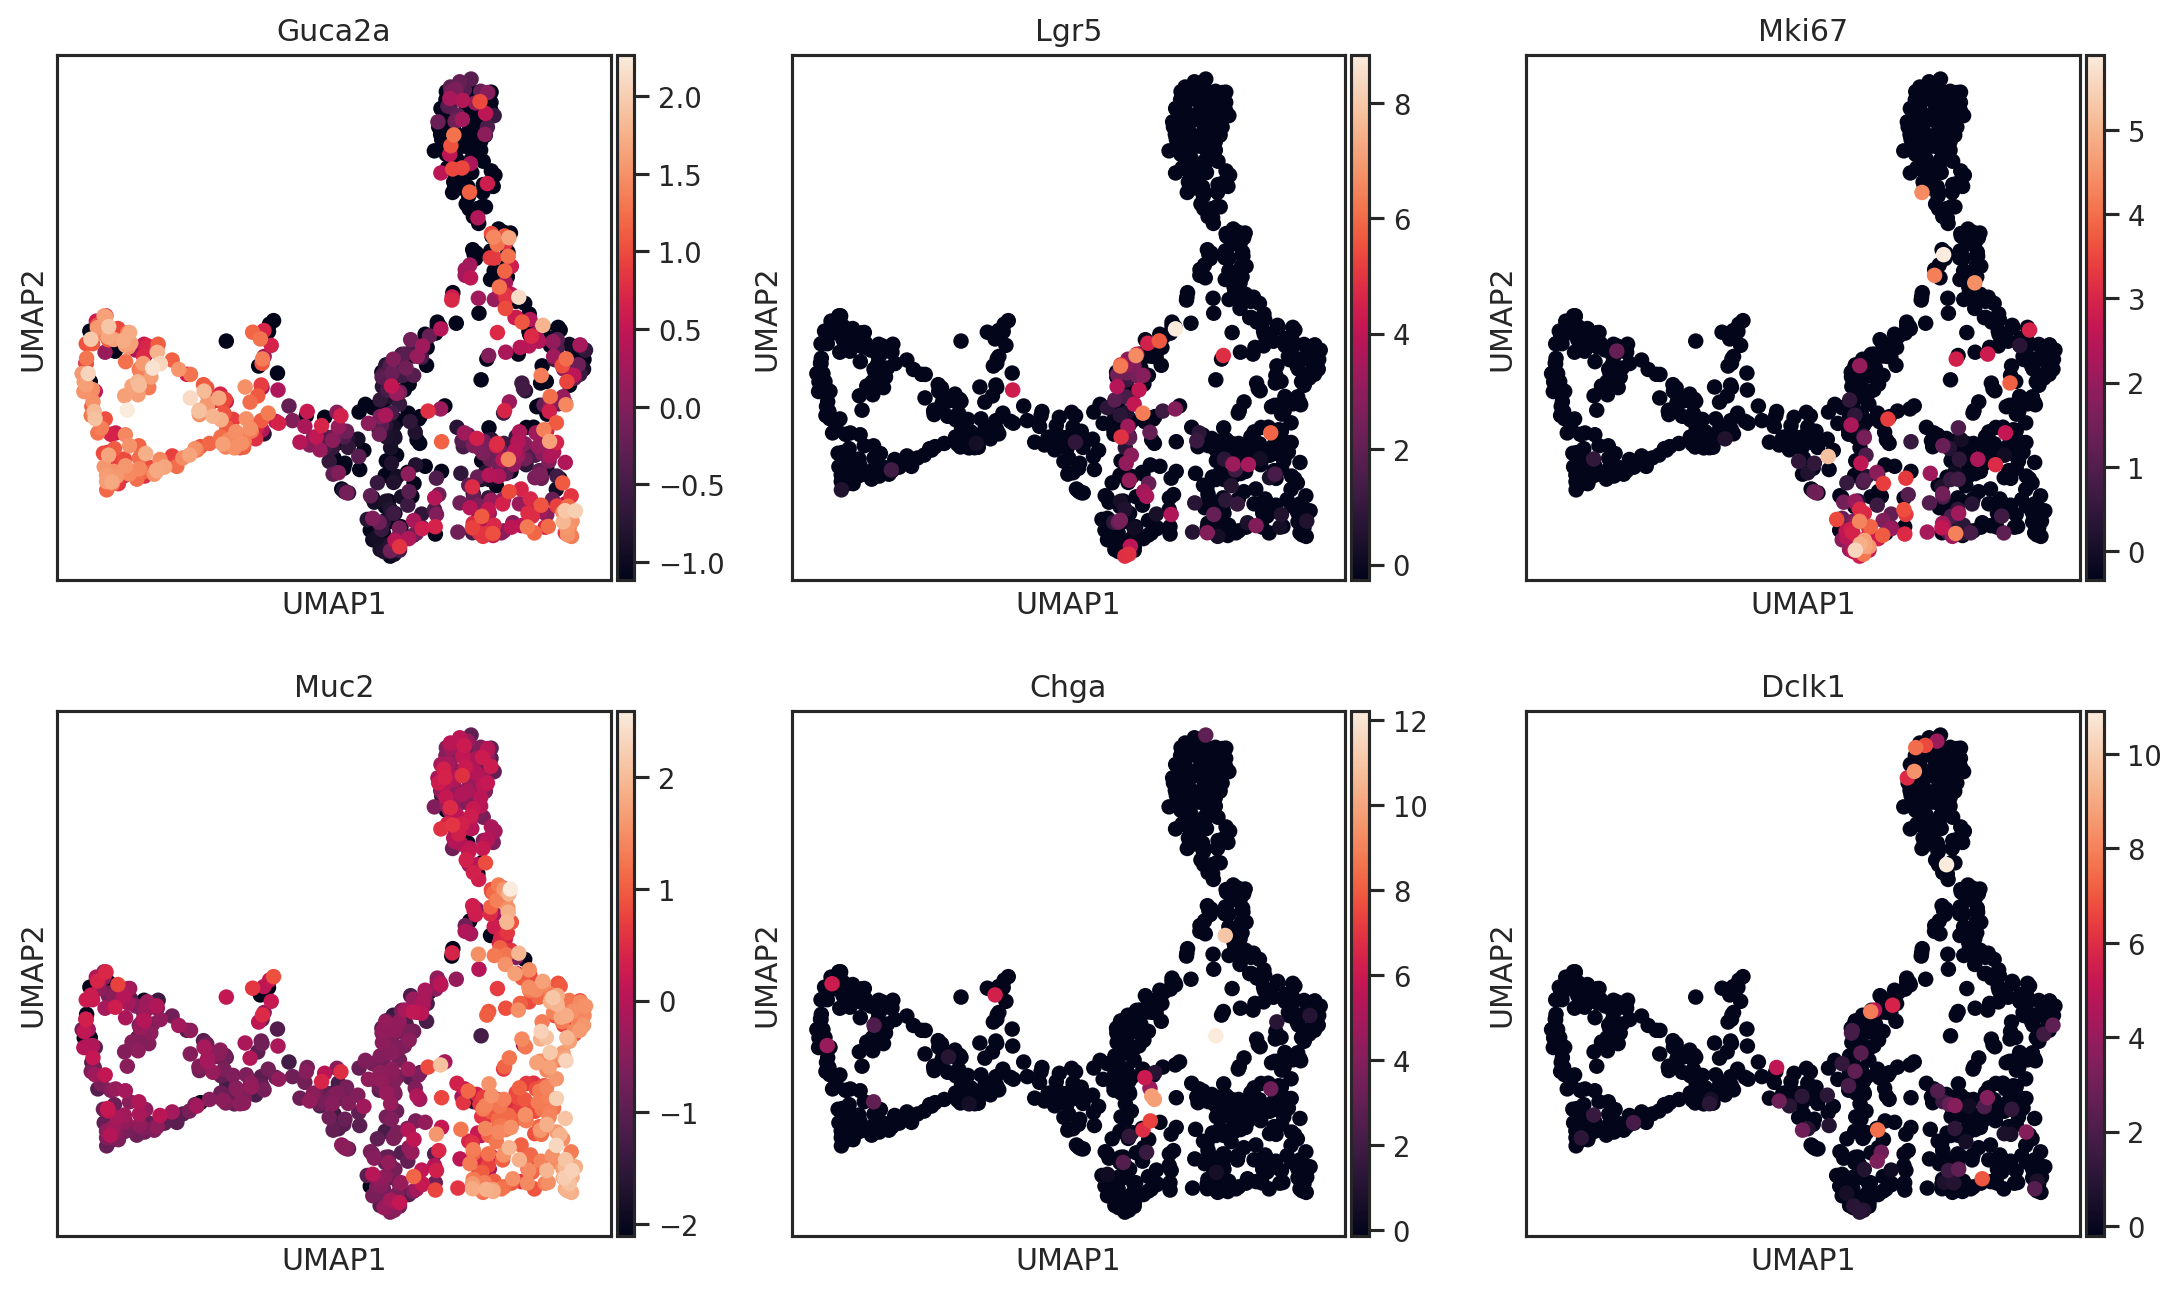

In [184]:
sc.pl.umap(filtered_dat, color = markers, ncols=3, use_raw= False)

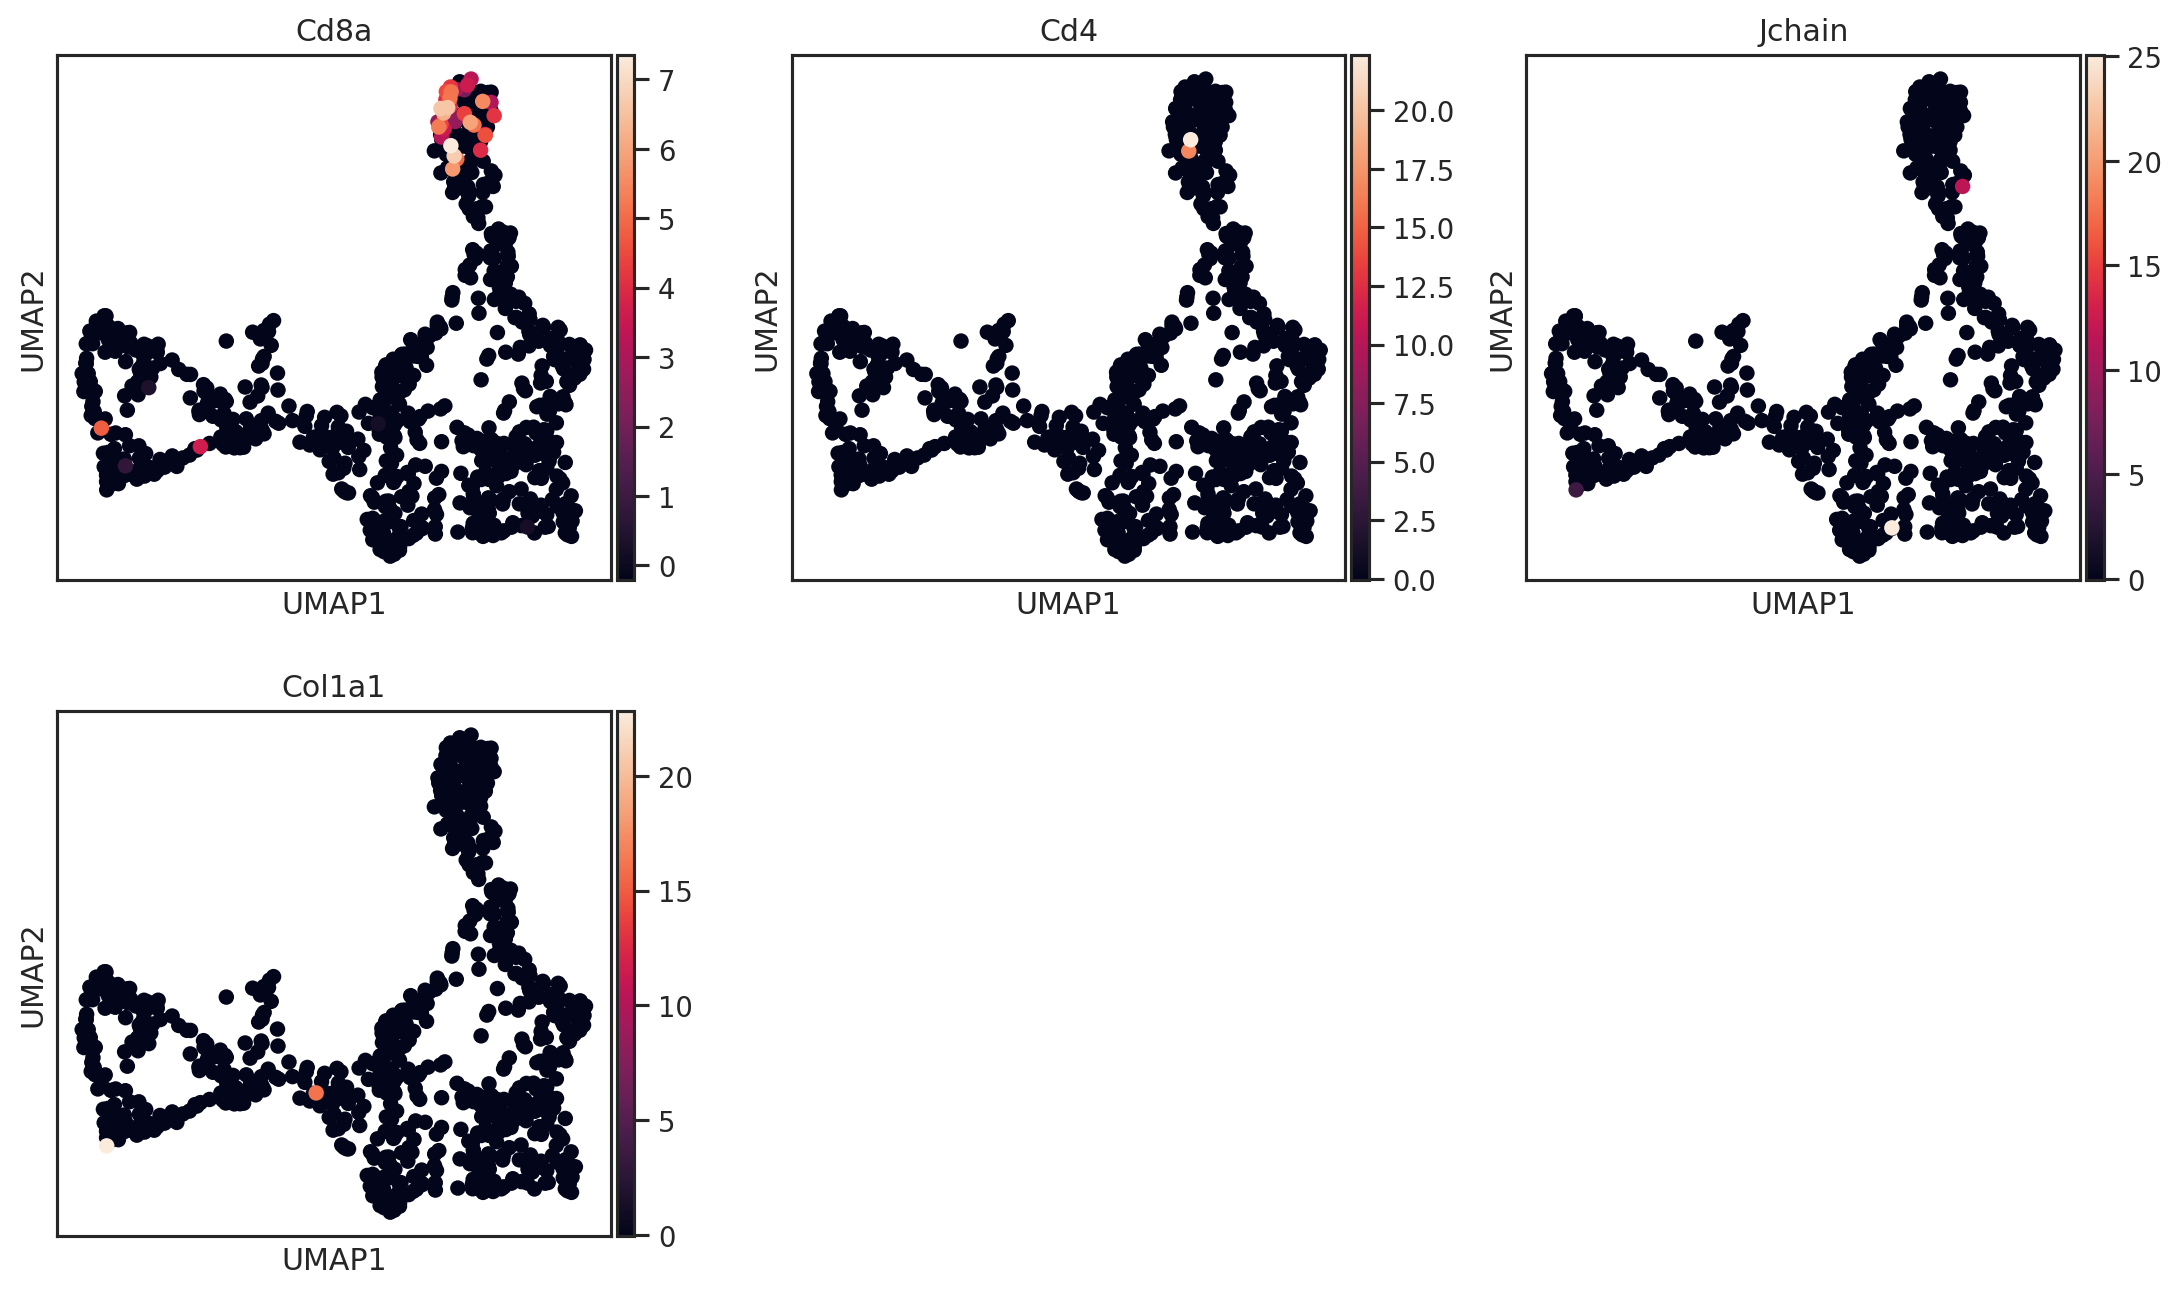

In [185]:
sc.pl.umap(filtered_dat, color = ne_markers, ncols=3, use_raw= False)